## CONFUSION MATRIX — MASTER CODE (ALL VARIATIONS)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

sns.set(style="whitegrid")
np.random.seed(42)


In [2]:
# Dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


### Train Model & Predictions

In [3]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


### Raw Confusion Matrix (Numeric)

In [4]:
cm = confusion_matrix(y_test, y_pred)
print(cm)


[[51  3]
 [ 2 87]]


### Confusion Matrix — Heatmap (Most Common)

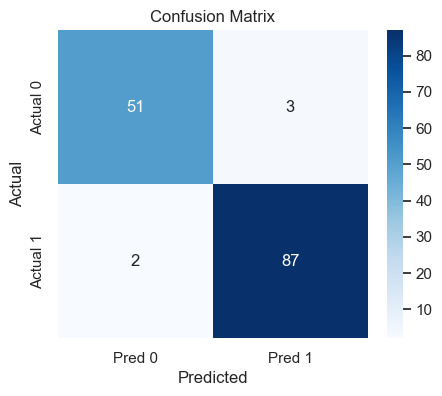

In [5]:
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["Actual 0", "Actual 1"]
)
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()


### Normalized Confusion Matrix (Percentages)

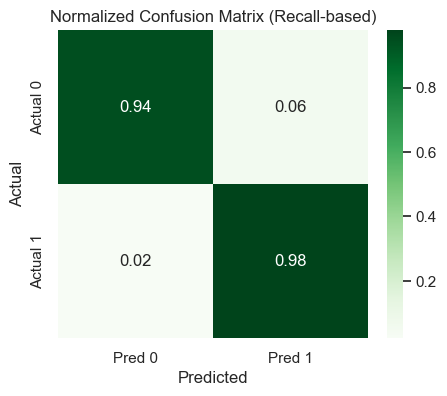

In [6]:
cm_norm = confusion_matrix(y_test, y_pred, normalize="true")

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["Actual 0", "Actual 1"]
)
plt.title("Normalized Confusion Matrix (Recall-based)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()


### Using Scikit-Learn Built-in Display

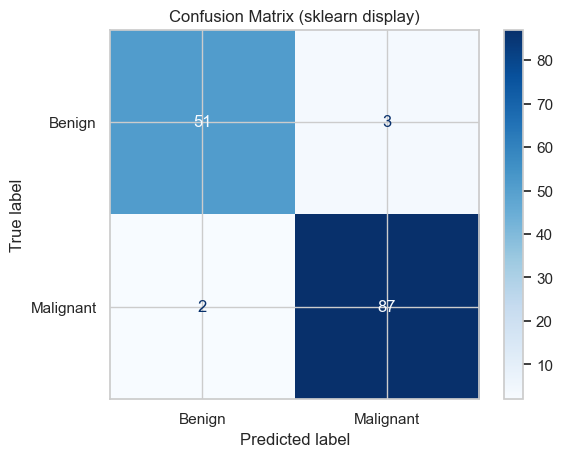

In [7]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix (sklearn display)")
plt.show()


### Annotated Confusion Matrix with Metrics

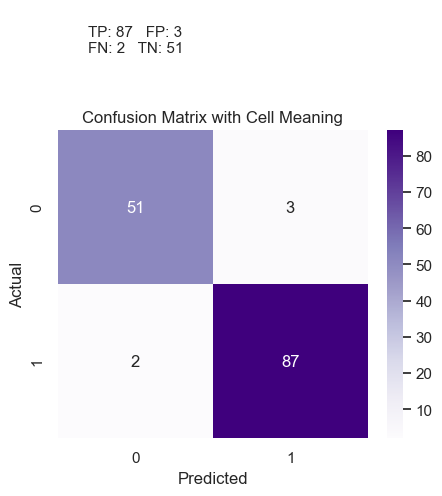

In [8]:
TN, FP, FN, TP = cm.ravel()

metrics_text = f"""
TP: {TP}   FP: {FP}
FN: {FN}   TN: {TN}
"""

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")
plt.text(0.5, -0.4, metrics_text, ha="center", fontsize=11)
plt.title("Confusion Matrix with Cell Meaning")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


### Multiclass Confusion Matrix (Template)

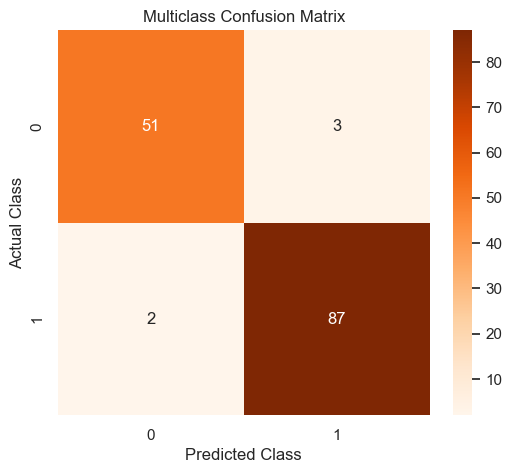

In [9]:
from sklearn.metrics import confusion_matrix

# Example: y_true, y_pred from multiclass model
cm_multi = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_multi, annot=True, fmt="d", cmap="Oranges")
plt.title("Multiclass Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()


### Confusion Matrix → Metrics (Derived)

In [10]:
accuracy = (TP + TN) / cm.sum()
precision = TP / (TP + FP)
recall = TP / (TP + FN)
specificity = TN / (TN + FP)
f1 = 2 * precision * recall / (precision + recall)

print(f"Accuracy     : {accuracy:.3f}")
print(f"Precision    : {precision:.3f}")
print(f"Recall       : {recall:.3f}")
print(f"Specificity  : {specificity:.3f}")
print(f"F1-score     : {f1:.3f}")


Accuracy     : 0.965
Precision    : 0.967
Recall       : 0.978
Specificity  : 0.944
F1-score     : 0.972
